In [8]:
import pandas as pd
import pickle as pk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df_raw = pd.read_csv('/content/data.csv')
df_clustered = pd.read_csv('/content/data_clustered.csv')

df_raw = df_raw[df_raw['price'] > 50000].reset_index(drop=True)
df_clustered = df_clustered[df_clustered['price'] > 50000].reset_index(drop=True)

df_raw['cluster_id'] = df_clustered['cluster_id'].values

city_means = df_raw.groupby('city')['price'].mean().to_dict()
df_raw['city_encoded'] = df_raw['city'].map(city_means)

df_raw['log_sqft_living'] = np.log1p(df_raw['sqft_living'])
df_raw['log_sqft_lot'] = np.log1p(df_raw['sqft_lot'])
df_raw['log_sqft_above'] = np.log1p(df_raw['sqft_above'])
df_raw['log_sqft_basement'] = np.log1p(df_raw['sqft_basement'])

city_clean_map = df_clustered[['city', 'city_clean']].drop_duplicates().set_index('city')['city_clean'].to_dict()
df_raw['city_clean'] = df_raw['city'].map(city_clean_map)

df = df_raw.copy()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(f"Loaded {len(df)} rows with RAW features")
print(df[['bedrooms','bathrooms','log_sqft_living','sqft_living','city_encoded','cluster_id']].head(3))

Loaded 4550 rows with RAW features
   bedrooms  bathrooms  log_sqft_living  sqft_living   city_encoded  cluster_id
0       3.0        1.5         7.201171         1340  420392.364047           0
1       5.0        2.5         8.202756         3650  584294.898165           1
2       3.0        2.0         7.565793         1930  441880.990543           0


In [10]:
feature_columns =['log_sqft_living'
, 'log_sqft_lot'
, 'log_sqft_above'
, 'log_sqft_basement'
, 'bedrooms'
, 'bathrooms'
, 'floors'
, 'view'
, 'condition'
,'yr_built'
, 'yr_renovated'
, 'waterfront'
, 'city_encoded']

target_column = ['cluster_id']
x = df[feature_columns].copy()
y = df[target_column].copy()
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()
pipelines = {
    "Logistic Regression Pipeline": Pipeline([
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "K-Nearest Neighbors Pipeline": Pipeline([
        ('classifier', KNeighborsClassifier(n_neighbors=4))
    ]),
    "Random Forest Pipeline": Pipeline([
        ('classifier', RandomForestClassifier(n_estimators=150, random_state=42))
    ]),
    "Gradient Boosting Pipeline": Pipeline([
        ('classifier', GradientBoostingClassifier(n_estimators=150, random_state=42))
    ])
}
pipeline_metrics = []

for pipe_name, pipe_obj in pipelines.items():
    pipe_obj.fit(x_train, y_train)

    y_pred = pipe_obj.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    pipeline_metrics.append({
        "Pipeline Architecture": pipe_name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4)
    })
df_pipe_comparison = pd.DataFrame(pipeline_metrics).sort_values(by="Accuracy", ascending=False)
print(df_pipe_comparison.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


       Pipeline Architecture  Accuracy  F1-Score
  Gradient Boosting Pipeline    0.9619    0.9619
      Random Forest Pipeline    0.9458    0.9456
Logistic Regression Pipeline    0.8857    0.8853
K-Nearest Neighbors Pipeline    0.7165    0.7071


In [11]:
winning_model = pipelines['Gradient Boosting Pipeline']
y_pred = winning_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       585
           1       0.95      0.95      0.95       263
           2       0.96      0.95      0.96       517

    accuracy                           0.96      1365
   macro avg       0.96      0.96      0.96      1365
weighted avg       0.96      0.96      0.96      1365



In [12]:
regression_features = [
    'log_sqft_living', 'log_sqft_lot', 'log_sqft_above', 'log_sqft_basement',
    'bedrooms', 'bathrooms', 'floors', 'view', 'condition',
    'yr_built', 'yr_renovated', 'waterfront', 'cluster_id', 'city_encoded'
]

X_reg = df[regression_features].copy()
X_reg = pd.get_dummies(X_reg, columns=['cluster_id'], drop_first=True)

y_reg = np.log(df['price']).copy().values
y_raw_price = df['price'].copy().values

X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(
    X_reg, y_reg, y_raw_price, test_size=0.2, random_state=42
)

reg_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)

y_pred_log = reg_model.predict(X_test)
y_pred_dollars = np.exp(y_pred_log)

r2 = r2_score(y_test, y_pred_log)
mae_dollars = mean_absolute_error(price_test, y_pred_dollars)

print("--- ALIGNED REGRESSION EVALUATION (LOG1P) ---")
print(f"Fixed R-squared (R²) Score: {r2:.4f}")
print(f"True Average Prediction Error: ${mae_dollars:,.2f}")

--- ALIGNED REGRESSION EVALUATION (LOG1P) ---
Fixed R-squared (R²) Score: 0.7253
True Average Prediction Error: $122,465.40


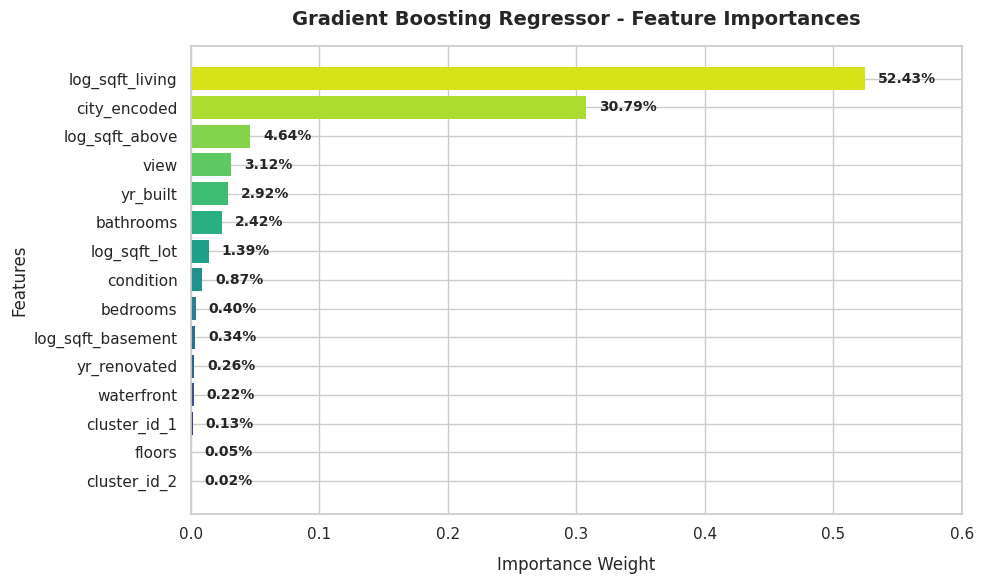

In [13]:
importances = reg_model.feature_importances_
feature_names = X_reg.columns

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
colors = sns.color_palette("viridis", len(df_imp))

bars = plt.barh(df_imp['Feature'], df_imp['Importance'], color=colors, edgecolor='none')
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width*100:.2f}%',
        va='center',
        ha='left',
        fontsize=10,
        weight='bold'
    )

plt.title('Gradient Boosting Regressor - Feature Importances', fontsize=14, weight='bold', pad=15)
plt.xlabel('Importance Weight', fontsize=12, labelpad=10)
plt.ylabel('Features', fontsize=12)
plt.xlim(0, 0.6)
plt.tight_layout()

plt.savefig('feature_importance_analysis.png', dpi=300)
plt.show()

In [14]:
with open('gradient_boosting_regression_model.pkl', 'wb') as f:
    pk.dump(reg_model, f)
with open('Gradient_Boosting_Pipeline.pkl','wb') as f:
    pk.dump(winning_model, f)